# Exploratory Data Analysis (EDA)
## Adult Census Income Dataset

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np


# Load processed data
try:
    df = pd.read_csv('../data/processed/final.csv')
    print("Data loaded successfully.")
except FileNotFoundError:
    print("Processed data not found. Please run the data pipeline first.")

Data loaded successfully.


### 1. Data Overview

In [2]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 32537 entries, 0 to 32536
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             32537 non-null  float64
 1   workclass       30701 non-null  str    
 2   fnlwgt          32537 non-null  float64
 3   education       32537 non-null  str    
 4   education.num   32537 non-null  float64
 5   marital.status  32537 non-null  str    
 6   occupation      30694 non-null  str    
 7   relationship    32537 non-null  str    
 8   race            32537 non-null  str    
 9   sex             32537 non-null  str    
 10  capital.gain    32537 non-null  float64
 11  capital.loss    32537 non-null  float64
 12  hours.per.week  32537 non-null  float64
 13  native.country  31955 non-null  str    
 14  income          32537 non-null  str    
dtypes: float64(6), str(9)
memory usage: 3.7 MB


In [3]:
df.describe()

,age,fnlwgt,education.num,capital.gain,capital.loss,hours.per.week
count,32537.000000,32537.000000,32537.000000,32537.0,32537.0,32537.000000
mean,38.559855,186824.961736,10.125165,0.0,0.0,41.203246
std,13.554847,95118.115529,2.459436,0.0,0.0,6.187352
min,17.000000,12285.000000,4.500000,0.0,0.0,32.500000
25%,28.000000,117827.000000,9.000000,0.0,0.0,40.000000
50%,37.000000,178356.000000,10.000000,0.0,0.0,40.000000
75%,48.000000,236993.000000,12.000000,0.0,0.0,45.000000
max,78.000000,415742.000000,16.000000,0.0,0.0,52.500000


### 2. Target Distribution
Analyze the distribution of the target variable `income`.

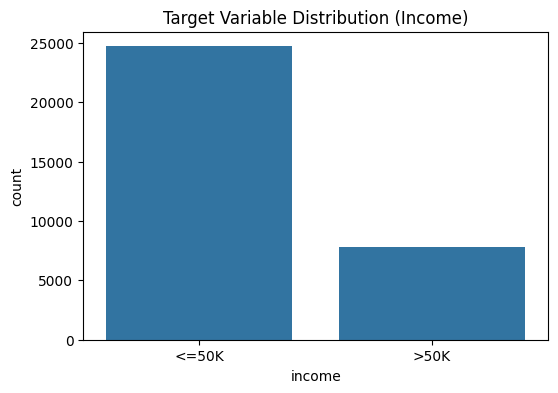

In [4]:
plt.figure(figsize=(6, 4))
sns.countplot(x='income', data=df)
plt.title('Target Variable Distribution (Income)')
plt.show()

### 3. Correlation Matrix
Correlation between numerical features.

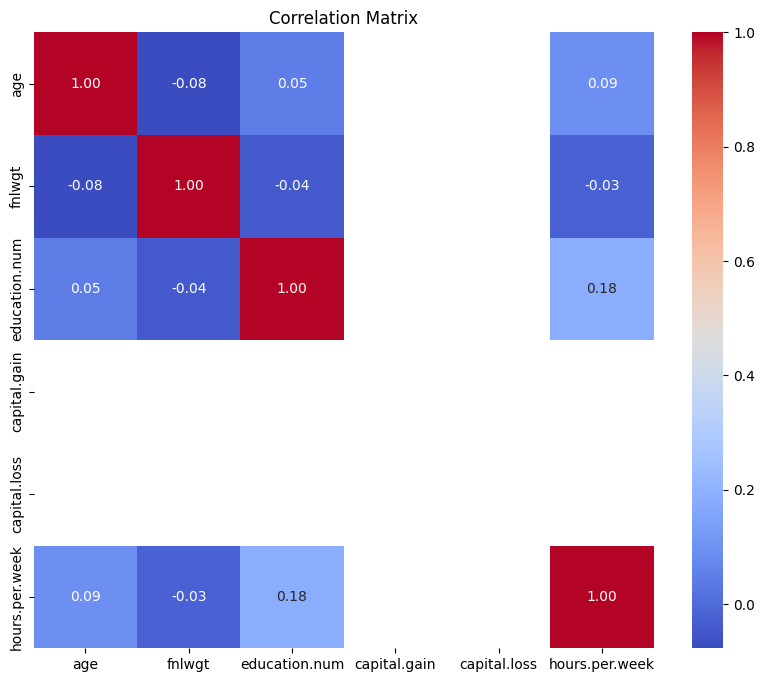

In [5]:
plt.figure(figsize=(10, 8))
numeric_df = df.select_dtypes(include=['number'])
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix')
plt.show()

### 4. Feature Distributions
Visualize distributions of key numerical features.

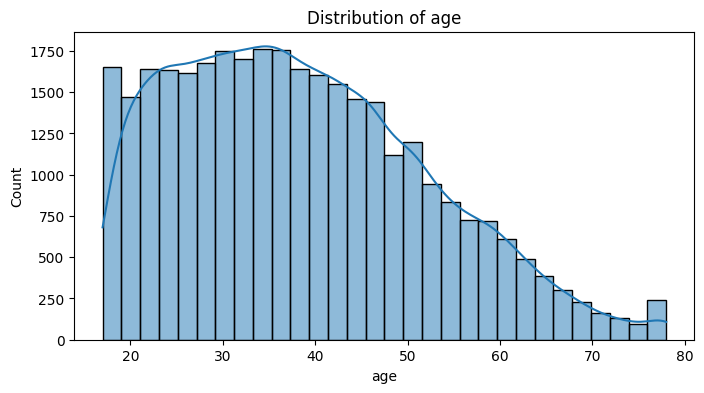

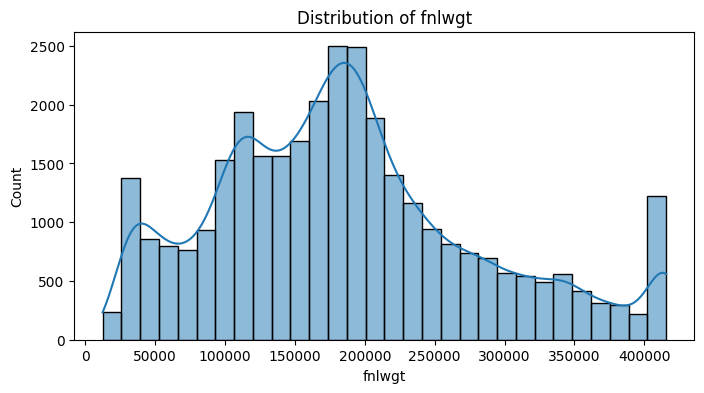

In [6]:
numeric_cols = ['age', 'fnlwgt', 'education-num', 'capital-gain', 'capital-loss', 'hours-per-week']
for col in numeric_cols:
    if col in df.columns:
        plt.figure(figsize=(8, 4))
        sns.histplot(df[col], kde=True, bins=30)
        plt.title(f'Distribution of {col}')
        plt.show()

### 5. Missing Values Heatmap

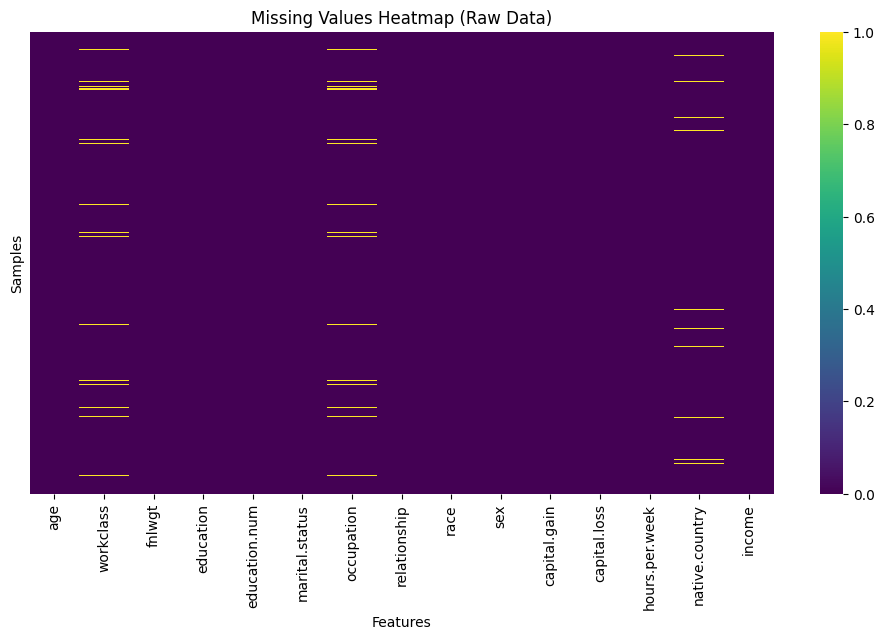

In [7]:
raw_df = pd.read_csv('../data/raw/adult.csv')
raw_df.replace('?', np.nan, inplace=True)
plt.figure(figsize=(12, 6))
sns.heatmap(raw_df.isnull(), cbar=True, cmap='viridis', yticklabels=False)
plt.title('Missing Values Heatmap (Raw Data)')
plt.xlabel('Features')
plt.ylabel('Samples')
plt.show()